In [3]:
import gymnasium as gym
import sys
import numpy as np
import matplotlib.pyplot as plt
sys.path.append("..")

In [4]:
from rlc.envs.fogofwar import FogGridEnv

env = FogGridEnv(render_mode="rgb_array")

print(f"Observation space: {env.observation_space}")
print(f"Action space:      {env.action_space}")
print(f"Render modes:      {env.metadata['render_modes']}")

obs, info = env.reset(seed=42)
print(f"Initial observation: {obs}  (row={obs // env.width}, col={obs % env.width})")

Observation space: Discrete(64)
Action space:      Discrete(4)
Render modes:      ['rgb_array']
Initial observation: 0  (row=0, col=0)


In [3]:
env = FogGridEnv(
    height=5,
    width=5,
    start_pos=(0, 0),
    goal_pos=(4, 4),
    obstacle_tiles=[
        (1, 1),
        (1, 2),
        (3, 3),
    ],
    trap_tiles=[
        (2, 2),
    ],
)

obs, info = env.reset()

print(obs)
print(env._agent_pos)

0
(0, 0)


In [4]:
obs, reward, terminated, truncated, info = env.step(1)

print(env._agent_pos)
print(reward)

(0, 1)
-1.0


In [5]:
obs, reward, terminated, truncated, info = env.step(1)

print(env._agent_pos)
print(reward)

(0, 2)
-1.0


In [6]:
obs, reward, terminated, truncated, info = env.step(2)

print(env._agent_pos)
print(reward)

(0, 2)
-1.0


In [7]:
env = FogGridEnv(
    height=12,
    width=12,
    start_pos=(0, 0),
    goal_pos=(11, 11),
    randomize_map=True,
    obstacle_density=0.1,
    trap_density=0.1,
)

env.reset(seed = 41)

env.print_map()

A . . X . X . . . . X .
O . . . . . . . . . X .
. . O . . . O . . X . .
O . . . . . O X O . . .
. . . O . . . . . . O .
. O O . . . . . . . . .
X X . . . . . . . . . .
X . . . . O . . X . O .
. . . . . . . . . X . .
. . . . X . . X . X . .
. . O . . . . . . . . .
. . . . . . . . O . . G


In [8]:
# based of a randomized map with seed = 41

fixed_obstacle_tiles = [(4, 10),
 (3, 8),
 (7, 5),
 (4, 3),
 (7, 10),
 (5, 1),
 (3, 0),
 (2, 6),
 (3, 6),
 (2, 2),
 (1, 0),
 (11, 8),
 (10, 2),
 (5, 2)]

fixed_trap_tiles = [(0, 10),
 (9, 9),
 (6, 1),
 (3, 7),
 (0, 3),
 (7, 0),
 (2, 9),
 (8, 9),
 (1, 10),
 (6, 0),
 (0, 5),
 (9, 7),
 (7, 8),
 (9, 4)]


In [9]:
from rlc.agents.q_learning import QLearningAgent
from rlc.utils.training import train

# Two environment instances: one for training, one for evaluation.
train_env = FogGridEnv(
    height=12,
    width=12,
    start_pos=(0, 0),
    goal_pos=(11, 11),
    randomize_map=False,
    obstacle_tiles= fixed_obstacle_tiles,
    trap_tiles=fixed_trap_tiles,
    render_mode="rgb_array")

eval_env = FogGridEnv(
    height=12,
    width=12,
    start_pos=(0, 0),
    goal_pos=(11, 11),
    randomize_map=False,
    obstacle_tiles= fixed_obstacle_tiles,
    trap_tiles=fixed_trap_tiles,
    render_mode="rgb_array")

agent = QLearningAgent(
    n_states=train_env.observation_space.n,
    n_actions=train_env.action_space.n,
    alpha=0.1,
    gamma=1.0,
    epsilon_start=1.0,
    epsilon_min=0.05,
    epsilon_decay=0.995
)

history = train(
    agent,
    train_env,
    n_episodes=1000,
    max_steps_per_episode=200,
    eval_every=50,
    eval_episodes=100,
    eval_env=eval_env,
    eval_max_steps=200,
    progress=True
)

print(f"Final epsilon:                     {agent.epsilon:.3f}")
print(f"Mean return, last 50 train eps:    {np.mean(history.episode_returns[-50:]):.1f}")
print(f"Final greedy evaluation return:    {history.eval_mean_returns[-1]:.1f} "
      f"(std {history.eval_std_returns[-1]:.1f})")

Training:   0%|          | 0/1000 [00:00<?, ?ep/s]

Final epsilon:                     0.050
Mean return, last 50 train eps:    74.7
Final greedy evaluation return:    79.0 (std 0.0)


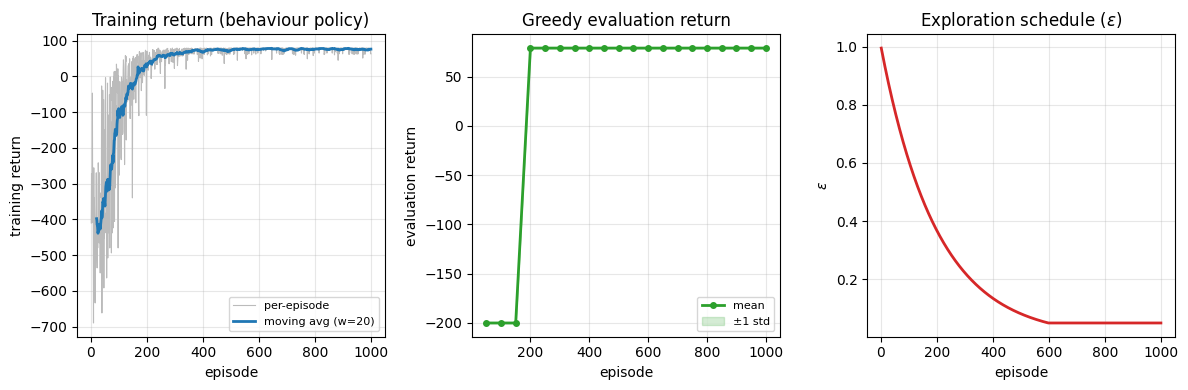

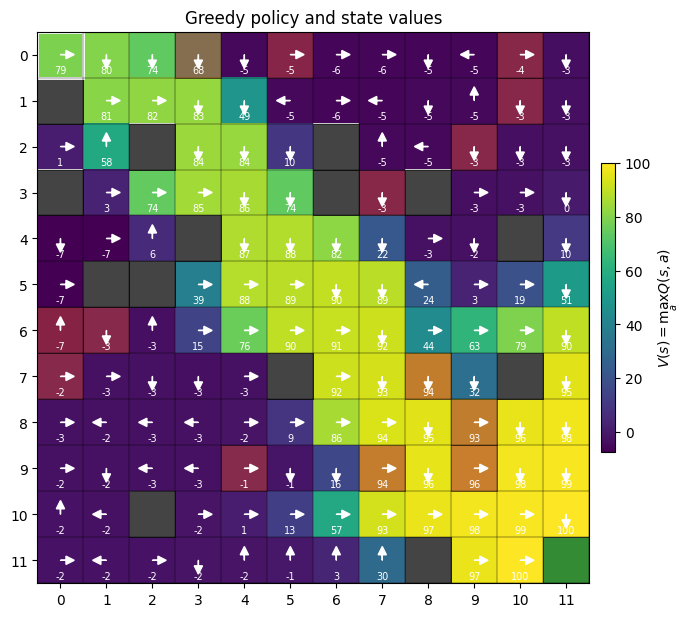

In [15]:
from rlc.utils.plotting import plot_learning_curves, plot_grid_policy_and_values

fig1 = plot_learning_curves(history)
plt.show()

fig2 = plot_grid_policy_and_values(agent, train_env, annotate_values=True, figsize = (7,7))
plt.show()

In [16]:
from rlc.agents.q_learning import QLearningAgent
from rlc.utils.training import train

# Two environment instances: one for training, one for evaluation.
train_env = FogGridEnv(
    height=12,
    width=12,
    start_pos=(0, 0),
    goal_pos=(11, 11),
    randomize_map=True,
    obstacle_density= 0.1,
    trap_density=0.1,
    render_mode="rgb_array")

eval_env = FogGridEnv(
    height=12,
    width=12,
    start_pos=(0, 0),
    goal_pos=(11, 11),
    randomize_map=True,
    obstacle_density= 0.1,
    trap_density=0.1,
    render_mode="rgb_array")

agent = QLearningAgent(
    n_states=train_env.observation_space.n,
    n_actions=train_env.action_space.n,
    alpha=0.1,
    gamma=1.0,
    epsilon_start=1.0,
    epsilon_min=0.05,
    epsilon_decay=0.995
)

history = train(
    agent,
    train_env,
    n_episodes=1000,
    max_steps_per_episode=200,
    eval_every=50,
    eval_episodes=100,
    eval_env=eval_env,
    eval_max_steps=200,
    progress=True
)

print(f"Final epsilon:                     {agent.epsilon:.3f}")
print(f"Mean return, last 50 train eps:    {np.mean(history.episode_returns[-50:]):.1f}")
print(f"Final greedy evaluation return:    {history.eval_mean_returns[-1]:.1f} "
      f"(std {history.eval_std_returns[-1]:.1f})")

Training:   0%|          | 0/1000 [00:00<?, ?ep/s]

Final epsilon:                     0.050
Mean return, last 50 train eps:    -80.5
Final greedy evaluation return:    -190.3 (std 69.2)


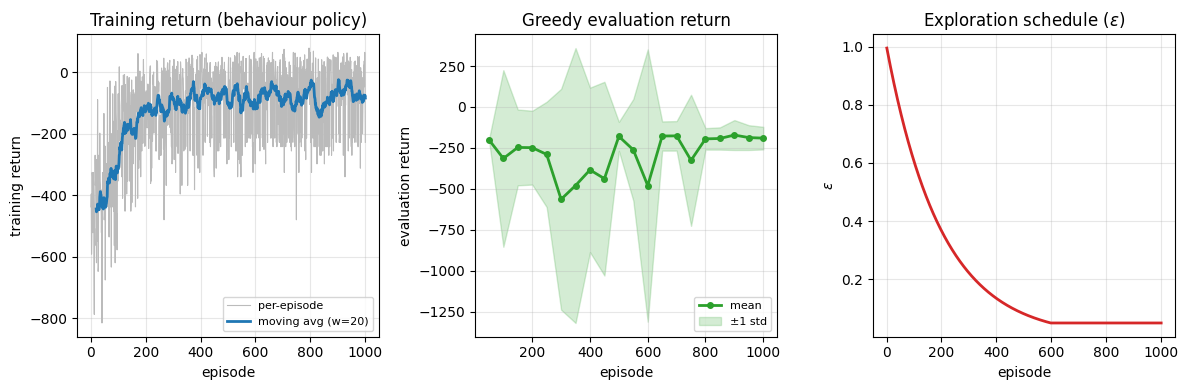

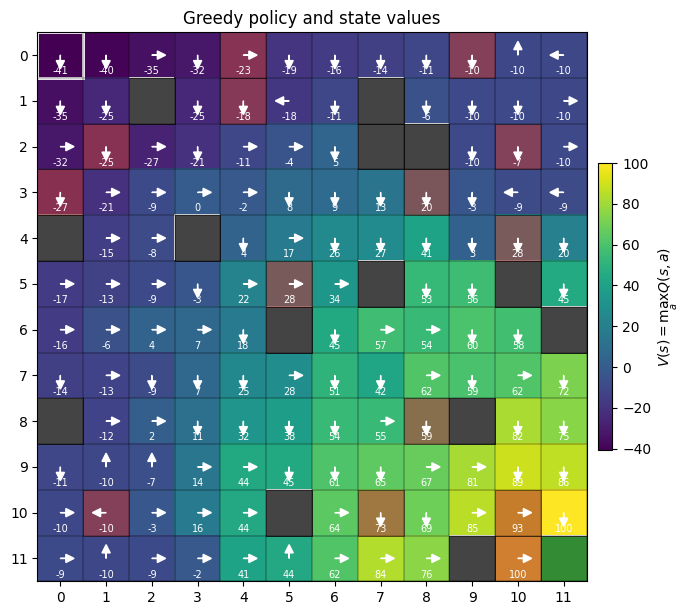

In [18]:
from rlc.utils.plotting import plot_learning_curves, plot_grid_policy_and_values

fig1 = plot_learning_curves(history)
plt.show()

fig2 = plot_grid_policy_and_values(agent, train_env, annotate_values=True, figsize = (7,7))
plt.show()

## Second agent

In [6]:
from rlc.agents.q_learning_wlocal import LocalQLearningAgent
from rlc.utils.training import train

# Two environment instances: one for training, one for evaluation.
train_env = FogGridEnv(
    height=12,
    width=12,
    start_pos=(0, 0),
    goal_pos=(11, 11),
    randomize_map=True,
    obstacle_density= 0.1,
    trap_density=0.1,
    vision_radius=2,
    local_view= True,
    render_mode="rgb_array")

eval_env = FogGridEnv(
    height=12,
    width=12,
    start_pos=(0, 0),
    goal_pos=(11, 11),
    randomize_map=True,
    obstacle_density= 0.1,
    trap_density=0.1,
    vision_radius=2,
    local_view= True,
    render_mode="rgb_array")

agent = LocalQLearningAgent(
    n_actions=train_env.action_space.n,
    alpha=0.1,
    gamma=1.0,
    epsilon_start=1.0,
    epsilon_min=0.05,
    epsilon_decay=0.995
)

history = train(
    agent,
    train_env,
    n_episodes=1000,
    max_steps_per_episode=200,
    eval_every=50,
    eval_episodes=100,
    eval_env=eval_env,
    eval_max_steps=200,
    progress=True
)

print(f"Final epsilon:                     {agent.epsilon:.3f}")
print(f"Mean return, last 50 train eps:    {np.mean(history.episode_returns[-50:]):.1f}")
print(f"Final greedy evaluation return:    {history.eval_mean_returns[-1]:.1f} "
      f"(std {history.eval_std_returns[-1]:.1f})")

Training:   0%|          | 0/1000 [00:00<?, ?ep/s]

Final epsilon:                     0.050
Mean return, last 50 train eps:    -75.4
Final greedy evaluation return:    -182.5 (std 83.7)


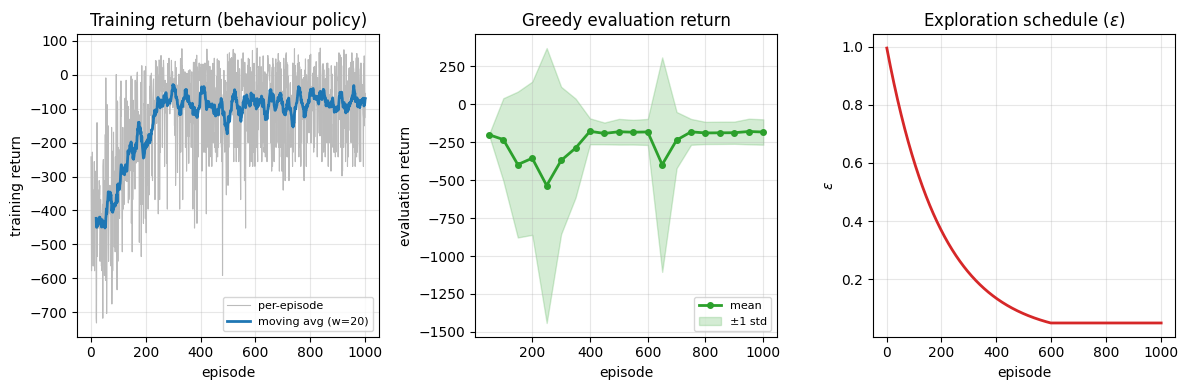

In [ ]:
from rlc.utils.plotting import plot_learning_curves

fig1 = plot_learning_curves(history)
plt.show()